In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

---

## 1. Load the dataset.

In [2]:
df = pd.read_csv('king_ country_ houses_aa.csv')
df = df.copy()

---

## 2. Explore the data to understand its structure — features, target variable, shape, and data types.

In [3]:
display(df.head())
display(df.info())
display(df.describe())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

None

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### Create a grid of histograms for all columns to have a quick glance at value ranges and distributions.

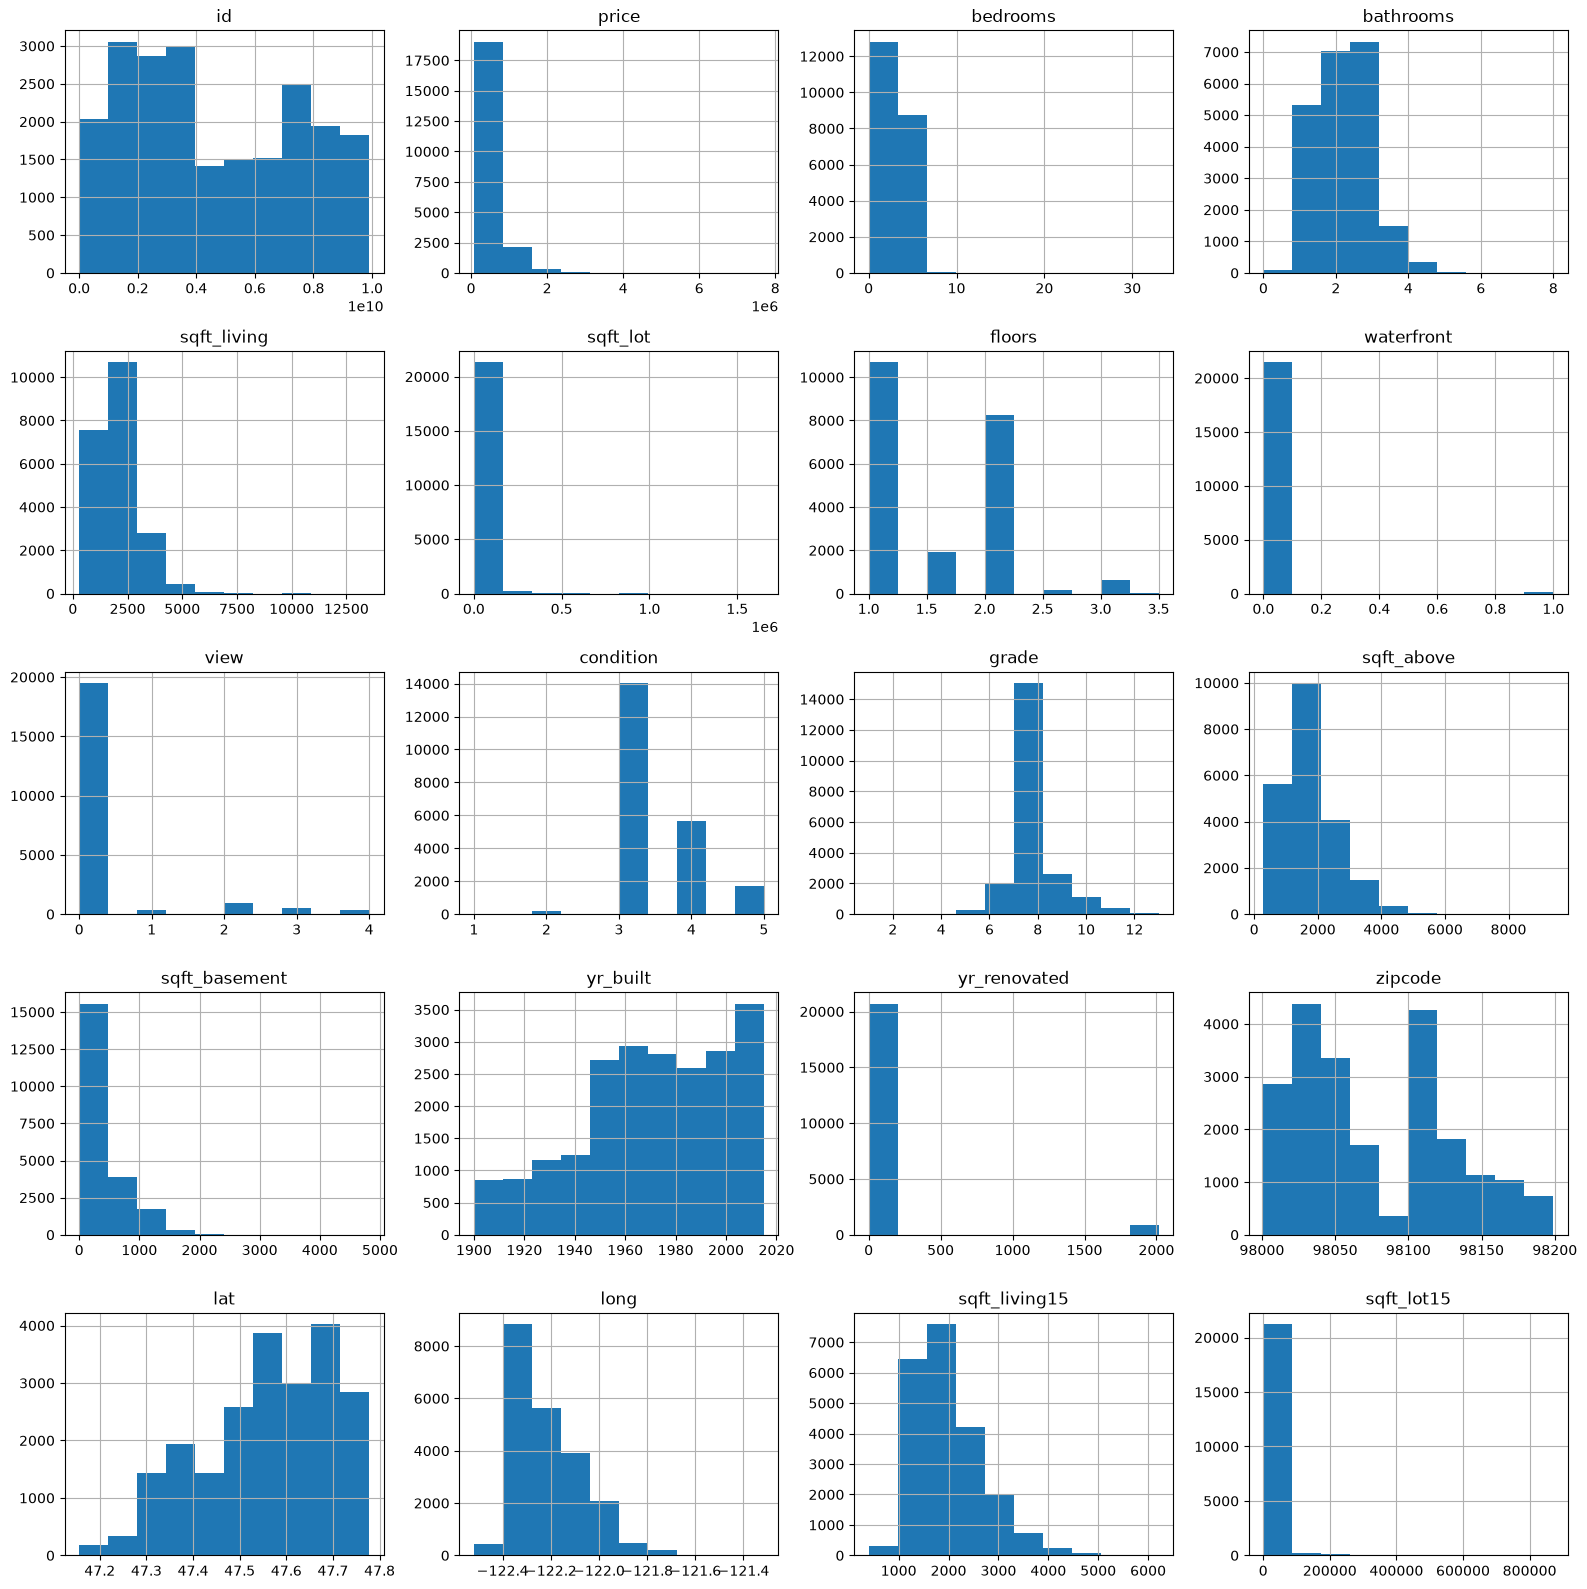

In [4]:
df.hist(figsize=(16,16))
plt.tight_layout()
plt.show()

---

## 3. Clean the dataset (handle duplicates, missing values, etc.).

### Check for duplicates and missing values

In [5]:
print(f'Duplicates: {df.duplicated().sum()}')
print(f'Missing values:\n{df.isnull().sum()}')

Duplicates: 0
Missing values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


### Avoid **Multicollinearity** and **Overfitting** by eliminating any correlation above 0.80
Identify and eliminate columns that carry almost the same information. This way we also avoid other problems, like making the column look more important than it is or the contrary, spliting the importance between two columns. 

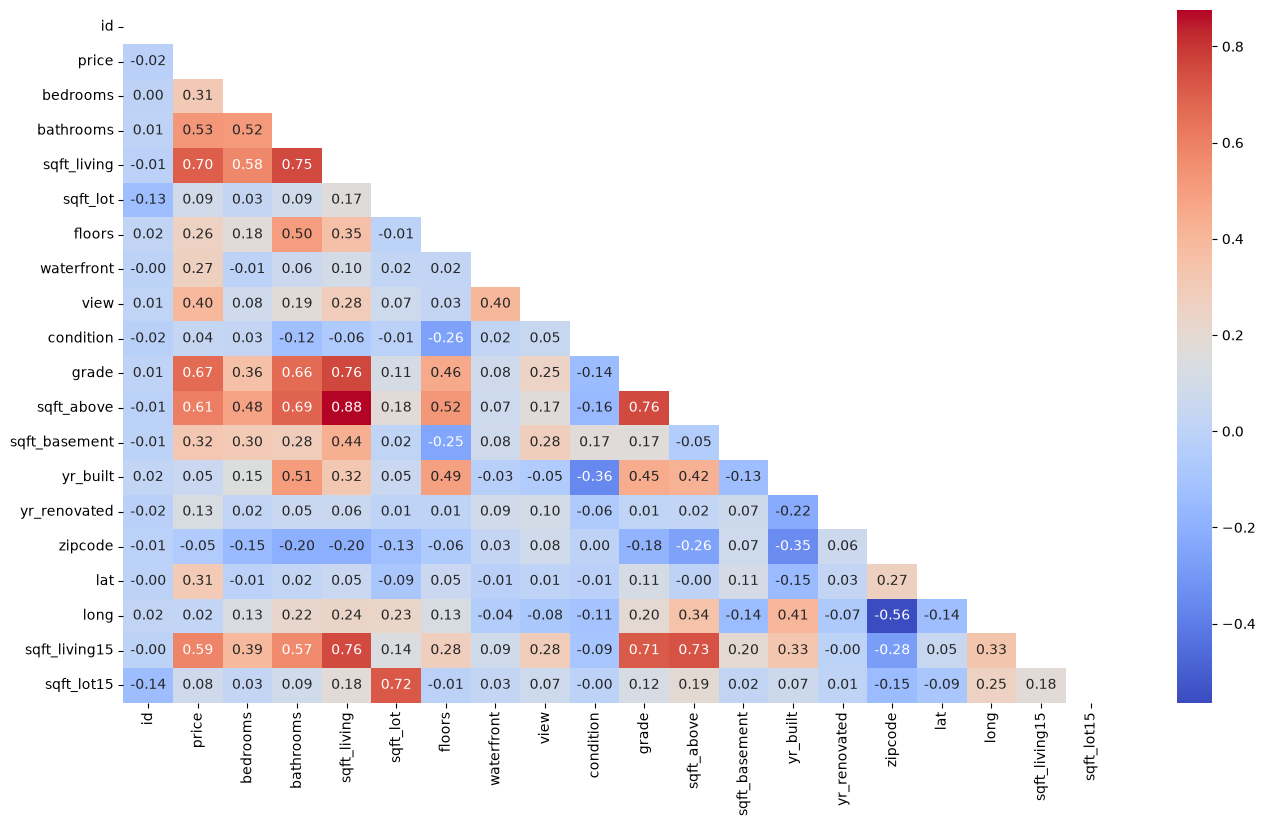

In [6]:
df_numerical = df.select_dtypes(include=["number"])
corr_matrix = df_numerical.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

plt.figure(figsize=(16,9))
sns.heatmap(corr_matrix, mask = mask, annot = True, fmt=".2f", cmap = 'coolwarm')
plt.show()

### Drop unusable columns
- **`id`**: Totally useless for our case, as it has zero mathematical relationship with a house's value.
- **`date`**: In its raw form, this feature is unusable by machine learning algorithms. Instead of completely discarding the data, we extracted its chronological value into `timeline_days` and dropped the original raw column.
- **`zipcode`**: We already have `lat` and `long` coordinates, making this column redundant. Furthermore, zipcode is a nominal category; leaving it as a raw number would confuse our models, while one-hot encoding it would create too many dimensions (columns), which is especially bad for a KNN Model (it would get lost in all those 70 columns).
- **`sqft_above`**: Dropped to prevent severe multicollinearity with `sqft_living`. There is absolutely no issue in dropping this column because it can be perfectly reconstructed at any time using our other features via the formula: `sqft_living` $=$ `sqft_above` $-$ `sqft_basement`.

In [7]:
df_ml = df.drop(columns = ['id','date', 'zipcode', 'sqft_above'])

In [8]:
# we created a new column based on date column, which instead of raw data, its a scaled numeric column which capture the exact chronological progression.
# Even tho it looks useless for a linear test, it is quiet useful for a KNN model for example.
df_ml['timeline_days'] = (
    pd.to_datetime(df['date'].str.slice(0,8), format = '%Y%m%d') - 
    pd.to_datetime(df['date'].str.slice(0,8), format = '%Y%m%d').min()
).dt.days

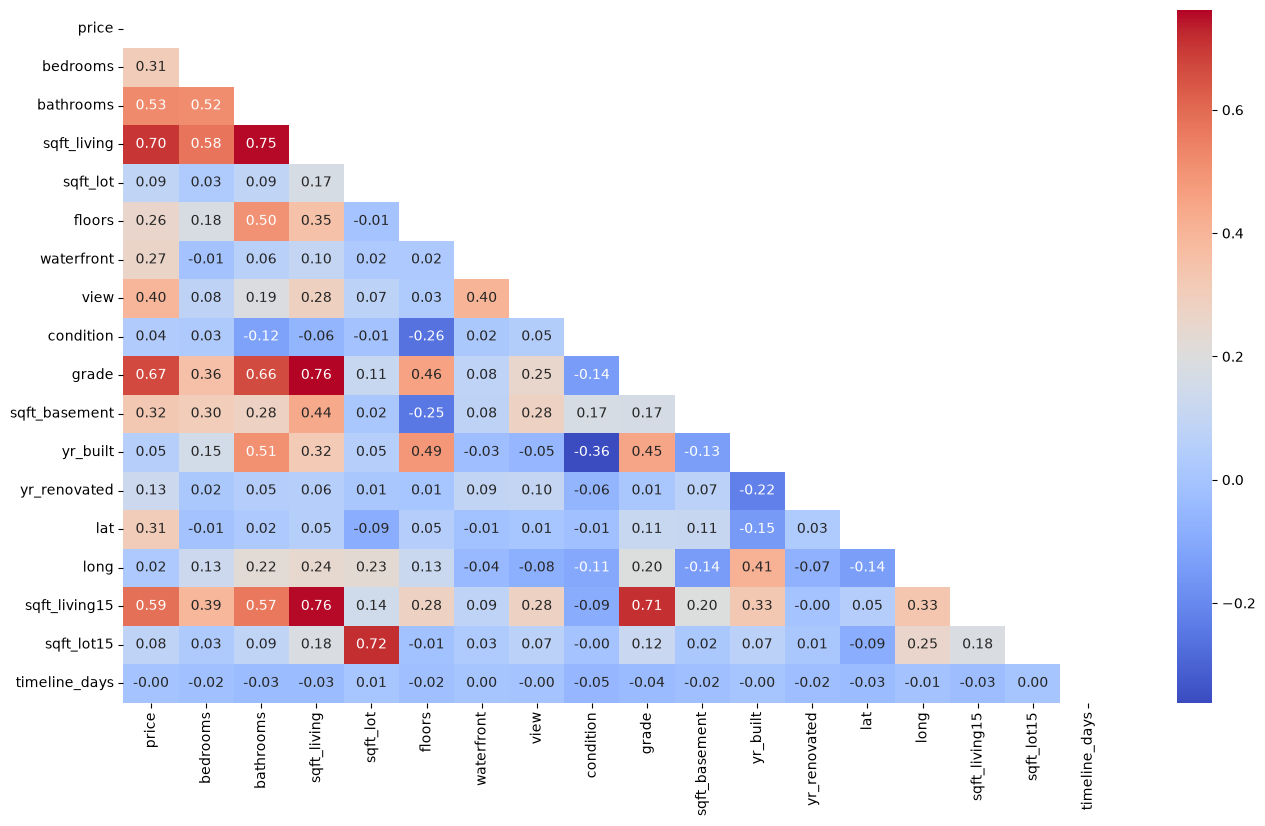

In [9]:
corr_matrix_ml = df_ml.corr()
mask_ml = np.triu(np.ones_like(corr_matrix_ml, dtype=bool))

plt.figure(figsize=(16,9))
sns.heatmap(corr_matrix_ml, mask = mask_ml, annot=True, fmt=".2f", cmap = 'coolwarm')
plt.show()

---

## 4. Split the dataset into features (X) and target (y).

In [10]:
X = df_ml.drop(columns=['price'])
y = df_ml['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

---

## 5. Explore correlations between the target and features, and among features. Include your interpretations.

We already explored the correlation matrix of the raw dataset in the cleaning process. Now we will perform an analysis strictly on our training set(`X_train` and `y_train`) to prevent data leakage.
To visually and mathematically check and prove that our training set is representative *(it perfectly captures all the characteristics, proportions and patterns of the bigger group it came from)* and unbiased *(the train did not favor any specific group, price point, or feature)*, we will audit data leakage by plotting the **Delta (Difference) Heatmap**:
$$\text{Correlation Shift} = \text{Original Correlation} - \text{Training Correlation}$$

In [11]:
# Calculate correlation matrices (Before vs. After Splitting)
corr_original = df_ml.corr()

df_train = X_train.copy()
df_train['price'] = y_train
corr_train = df_train.corr()

# Subtract to isolate the exact mathematical difference (Correlation Shift)
corr_diff = corr_original - corr_train

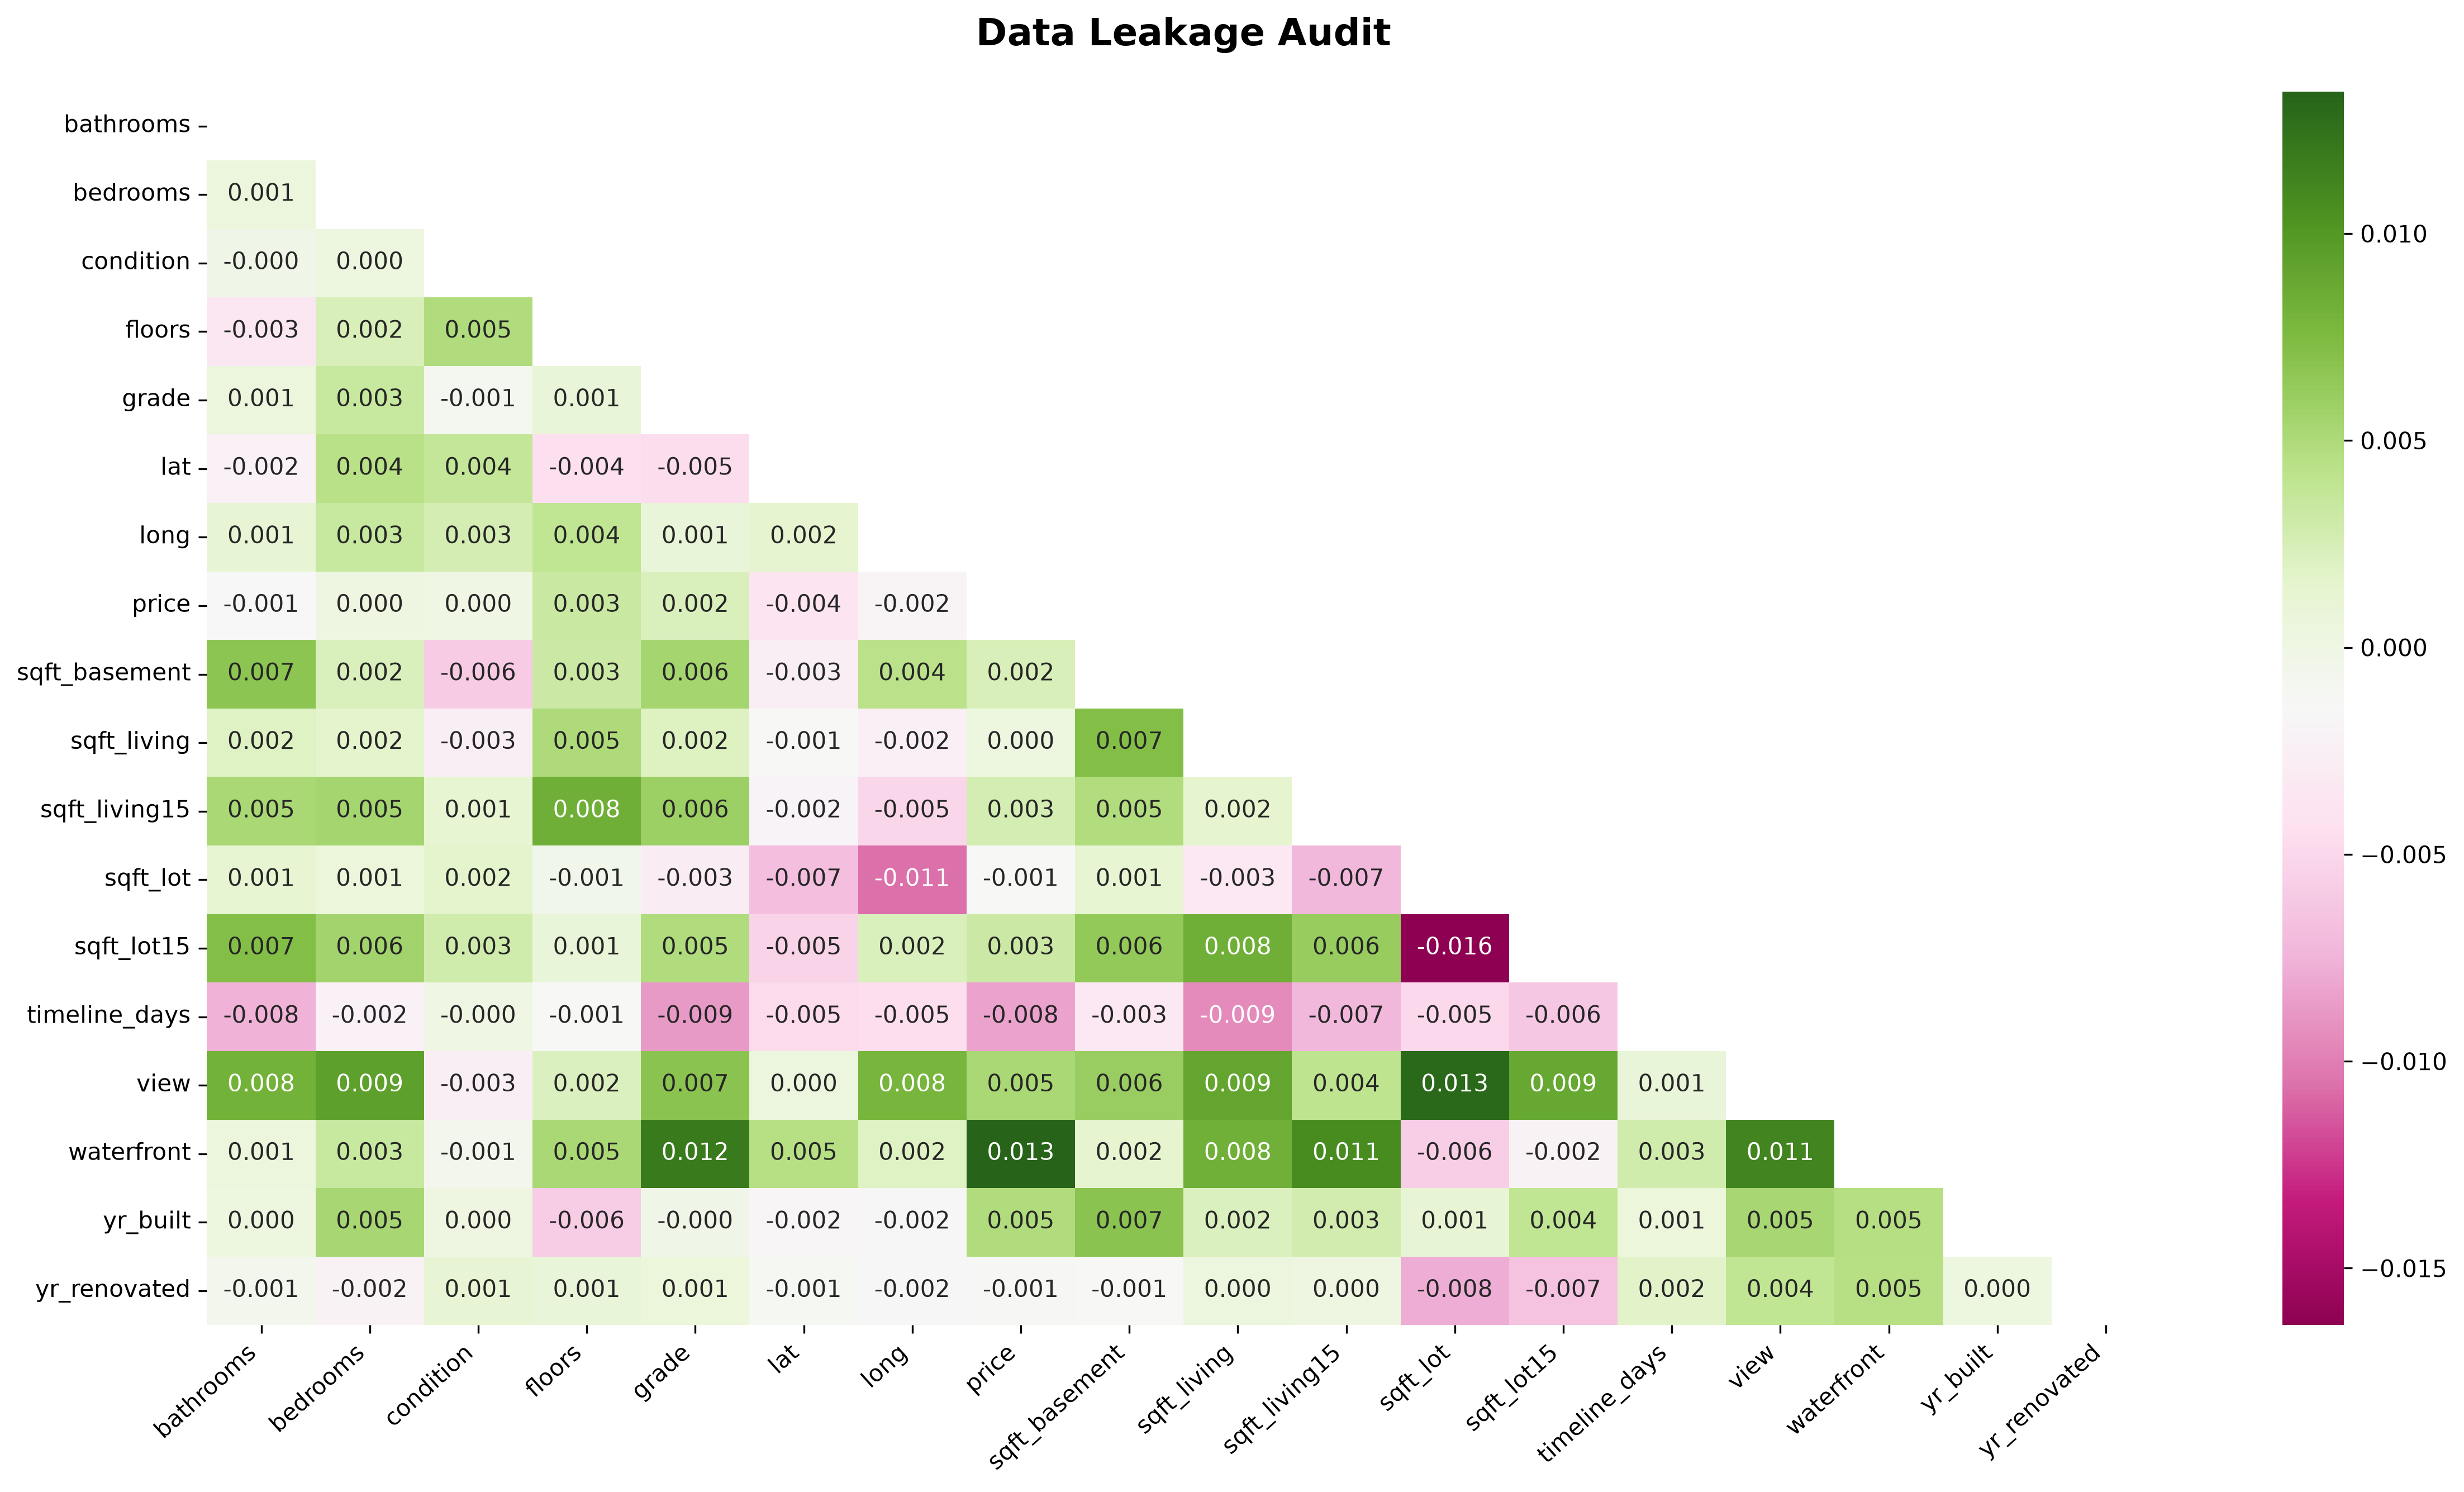

In [12]:
mask_diff = np.triu(np.ones_like(corr_diff, dtype=bool))    # Create an upper-triangle mask to keep the visualization clean


plt.figure(figsize= (16, 9), dpi = 300)

sns.heatmap(corr_diff, 
    mask=mask_diff, 
    annot=True, 
    fmt=".3f",       # Show 3 decimals to catch tiny shifts
    cmap='PiYG'
)
plt.title("Data Leakage Audit", fontsize = 16, fontweight = "bold", pad = 20 )
plt.xticks(rotation = 42, ha = 'right')
plt.tight_layout()
plt.show()

---

## 6. Handle categorical variables (encoding).

In [13]:
explicit_cat_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()   # Check for explicit categorical where columns non numerical.
print("Explicit categorical columns:", explicit_cat_columns)
print("Unique values per column:")
print(X_train.nunique().sort_values())                                                          # Show the amount of unique values per column.

Explicit categorical columns: []
Unique values per column:
waterfront          2
view                5
condition           5
floors              6
bedrooms           12
grade              12
bathrooms          29
yr_renovated       70
yr_built          116
sqft_basement     288
timeline_days     368
sqft_living15     710
long              724
sqft_living       923
lat              4846
sqft_lot15       7558
sqft_lot         8406
dtype: int64


To determine if any encoding (such as One-Hot Encoding) is required, we analyzed the unique value counts and data types of our features:
* **No explicit categorical columns**: Our features contain zero string/text data types (`object` or `category`). 
* **Naturally encoded binary features**: The `waterfront` column is already represented as binary integers ($0$ and $1$). The column is already in the absolute perfect format for machine learning.
* **Naturally encoded ordinal features**: Features like `view`, `condition`, ... , `grade` already use ordered numeric scales.
  * **Preserving mathematical "closeness" (using `grade` as an example)**: Keeping these numeric is crucial for our distance-based models. If we one-hot encoded them, the model would completely lose its ability to recognize that a `grade` $8$ house is highly similar to a `grade` $9$ house. Instead, the mathematical distance between `grade` $8$ and $9$ would look exactly the same as the distance between `grade` $2$ and grade $11$.

**Conclusion:** No explicit encoding is necessary. The dataset is entirely numeric and structured perfectly for our distance-based, tree-based and linear models.

*Note: While one-hot encoding numerical categories can sometimes help tree-based models capture highly specific non-linear quirks, it is generally a bad idea for distance-based and linear models where the natural numeric order, distance, and linear relationships of ordinal scales are incredibly valuable assets.*

---

## 7. Train baseline models such as Linear Regression and KNN Regressor.

### Feature Scaling
Based on our previous evaluation, it is mandatory to execute a Feature Scaling on our dataset.
1. For Distance-Based models
    n/ If we don't scale, a 1 sqft will be mathematically treated the same as 1 bedroom, which we know it's not plausible in real life.
2. For Linear Regression
    It won't break the models, but it is highly recommended as it allows us directly compare which feature has the strongest impact.
3. For Regularized Linear Models
   This models penalize the size of the coefficients, so scaling is 100% mandatory.

Tree-Based Models are scale-invariant. What it means is they do not care about scaling at all because all it does is compare ($>$ or $<$) one value to the next. It only cares about the order of the values, not their absolute size.

In [14]:
scaler = StandardScaler()
scaler.set_output(transform = "pandas")    #Force the scaler to output a Pandas DataFrame

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
display(X_train_scaled)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,timeline_days
6325,-0.395263,-0.474451,-0.323933,-0.043873,-0.919600,-0.084992,-0.305917,0.909073,1.150243,-0.656310,0.404001,-0.208294,-1.396608,0.442288,1.126073,0.013440,-1.371427
13473,-1.468964,-1.452583,-1.183653,-0.285775,-0.919600,-0.084992,-0.305917,-0.625426,-1.413156,-0.200433,-1.430565,-0.208294,-0.060172,-0.539958,-1.046523,-0.280662,1.168989
17614,-0.395263,-1.452583,-1.095477,-0.188293,0.001545,-0.084992,-0.305917,-0.625426,-1.413156,-0.451165,-0.988910,-0.208294,-0.552847,-0.860256,-1.193320,-0.178934,1.062770
16970,-0.395263,0.177636,0.017751,-0.187933,-0.919600,-0.084992,-0.305917,0.909073,-0.558690,1.189993,0.200160,-0.208294,-1.193614,0.299934,-0.268498,-0.195283,0.629040
20868,-1.468964,0.503680,-0.366919,-0.343991,0.922690,-0.084992,-0.305917,-0.625426,0.295777,0.016109,1.219364,-0.208294,1.040039,0.036578,0.157213,-0.082511,1.505351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,-0.395263,-0.800495,-1.183653,-0.203021,-0.919600,-0.084992,-0.305917,-0.625426,-0.558690,-0.656310,-0.819043,-0.208294,1.113001,-0.746372,-1.442875,-0.209925,0.133349
21575,-0.395263,0.503680,1.116650,-0.252251,0.922690,-0.084992,-0.305917,-0.625426,0.295777,-0.656310,1.457178,-0.208294,-1.899396,-0.959904,1.385904,-0.274013,0.115646
5390,-0.395263,0.503680,0.050817,-0.257967,0.922690,-0.084992,-0.305917,-0.625426,-0.558690,-0.656310,1.117443,-0.208294,0.871720,1.296416,-0.429975,-0.366040,-0.256122
860,-2.542664,-1.778627,-1.867021,0.005177,-0.919600,-0.084992,-0.305917,-0.625426,-2.267622,-0.656310,-0.275468,-0.208294,-0.573075,-0.774843,-1.193320,0.082652,-1.158988


### Training

### Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
lr_model_unscaled = LinearRegression()
lr_model_unscaled.fit(X_train, y_train)

y_pred_lr = lr_model_unscaled.predict(X_test)

r2_lr_unscaled = r2_score(y_test, y_pred_lr)
rmse_lr_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f'R² Score: {r2_lr_unscaled}')
print(f'RMSE (Avg Error): {rmse_lr_unscaled}')

R² Score: 0.6969662779674242
RMSE (Avg Error): 214036.54314121918


In [18]:
lr_model_scaled = LinearRegression()
lr_model_scaled.fit(X_train_scaled, y_train)

y_pred_lr = lr_model_scaled.predict(X_test_scaled)

r2_lr_scaled = r2_score(y_test, y_pred_lr)
rmse_lr_scaled = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f'R² Score: {r2_lr_scaled}')
print(f'RMSE (Avg Error): {rmse_lr_scaled}')

R² Score: 0.6969662779674286
RMSE (Avg Error): 214036.54314121764


### Ridge (Regularized linear model)

In [19]:
from sklearn.linear_model import Ridge

In [20]:
ridge_unscaled = Ridge(alpha=1.0)
ridge_unscaled.fit(X_train, y_train)

y_pred_ridge_unscaled = ridge_unscaled.predict(X_test)
r2_ridge_unscaled = r2_score(y_test, y_pred_ridge_unscaled)
rmse_ridge_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_ridge_unscaled))

print(f'R² Score: {r2_ridge_unscaled}')
print(f'RMSE (Avg Error): {rmse_ridge_unscaled}')

R² Score: 0.6969042768784655
RMSE (Avg Error): 214058.43809723572


In [21]:
ridge_scaled = Ridge(alpha=1.0)
ridge_scaled.fit(X_train_scaled, y_train)

y_pred_ridge_scaled = ridge_scaled.predict(X_test_scaled)
r2_ridge_scaled = r2_score(y_test, y_pred_ridge_scaled)
rmse_ridge_scaled = np.sqrt(mean_squared_error(y_test, y_pred_ridge_scaled))

print(f'R² Score: {r2_ridge_scaled}')
print(f'RMSE (Avg Error): {rmse_ridge_scaled}')

R² Score: 0.6969643679939597
RMSE (Avg Error): 214037.21765934036


### K-Nearest Neighbors (Distance-based model)

In [22]:
from sklearn.neighbors import KNeighborsRegressor

In [23]:
knn_unscaled = KNeighborsRegressor(n_neighbors = 5)
knn_unscaled.fit(X_train, y_train)

y_pred_knn_unscaled = knn_unscaled.predict(X_test)
r2_knn_unscaled = r2_score(y_test, y_pred_knn_unscaled)
rmse_knn_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_knn_unscaled))

print(f'R² Score: {r2_knn_unscaled}')
print(f'RMSE (Avg Error): {rmse_knn_unscaled}')

R² Score: 0.4990107252288205
RMSE (Avg Error): 275205.2169488323


In [24]:
knn_scaled = KNeighborsRegressor(n_neighbors = 5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)
r2_knn_scaled = r2_score(y_test, y_pred_knn_scaled)
rmse_knn_scaled = np.sqrt(mean_squared_error(y_test, y_pred_knn_scaled))

print(f'R² Score: {r2_knn_scaled}')
print(f'RMSE (Avg Error): {rmse_knn_scaled}')

R² Score: 0.7717230520769536
RMSE (Avg Error): 185769.0998821812


### Random Forest Regressor (Tree-based model)

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
rf_unscaled = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_unscaled.fit(X_train, y_train)

y_pred_rf_unscaled = rf_unscaled.predict(X_test)
r2_rf_unscaled = r2_score(y_test, y_pred_rf_unscaled)
rmse_rf_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_rf_unscaled))

print(f'R² Score: {r2_rf_unscaled}')
print(f'RMSE (Avg Error): {rmse_rf_unscaled}')

R² Score: 0.8510821743559948
RMSE (Avg Error): 150043.0180891484


In [27]:
rf_scaled = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_scaled.fit(X_train_scaled, y_train)

y_pred_rf_scaled = rf_scaled.predict(X_test_scaled)
r2_rf_scaled = r2_score(y_test, y_pred_rf_scaled)
rmse_rf_scaled = np.sqrt(mean_squared_error(y_test, y_pred_rf_scaled))

print(f'R² Score: {r2_rf_scaled}')
print(f'RMSE (Avg Error): {rmse_rf_scaled}')

R² Score: 0.8509372409938256
RMSE (Avg Error): 150116.01455704047


### Gradient Boosting

In [28]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [29]:
hgb_model_unscaled = HistGradientBoostingRegressor(random_state = 42)
hgb_model_unscaled.fit(X_train, y_train)

y_pred_hgb_unscaled = hgb_model_unscaled.predict(X_test)
r2_hgb_unscaled = r2_score(y_test, y_pred_hgb_unscaled)
rmse_hgb_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_hgb_unscaled))

print(f'R² Score: {r2_hgb_unscaled}')
print(f'RMSE (Avg Error): {rmse_hgb_unscaled}')

R² Score: 0.877243157624851
RMSE (Avg Error): 136227.66179197302


In [30]:
hgb_model_scaled = HistGradientBoostingRegressor(random_state = 42)
hgb_model_scaled.fit(X_train_scaled, y_train)

y_pred_hgb_scaled = hgb_model_scaled.predict(X_test_scaled)
r2_hgb_scaled = r2_score(y_test, y_pred_hgb_scaled)
rmse_hgb_scaled = np.sqrt(mean_squared_error(y_test, y_pred_hgb_scaled))

print(f'R² Score: {r2_hgb_scaled}')
print(f'RMSE (Avg Error): {rmse_hgb_scaled}')

R² Score: 0.877243157624851
RMSE (Avg Error): 136227.66179197302


### Comparison

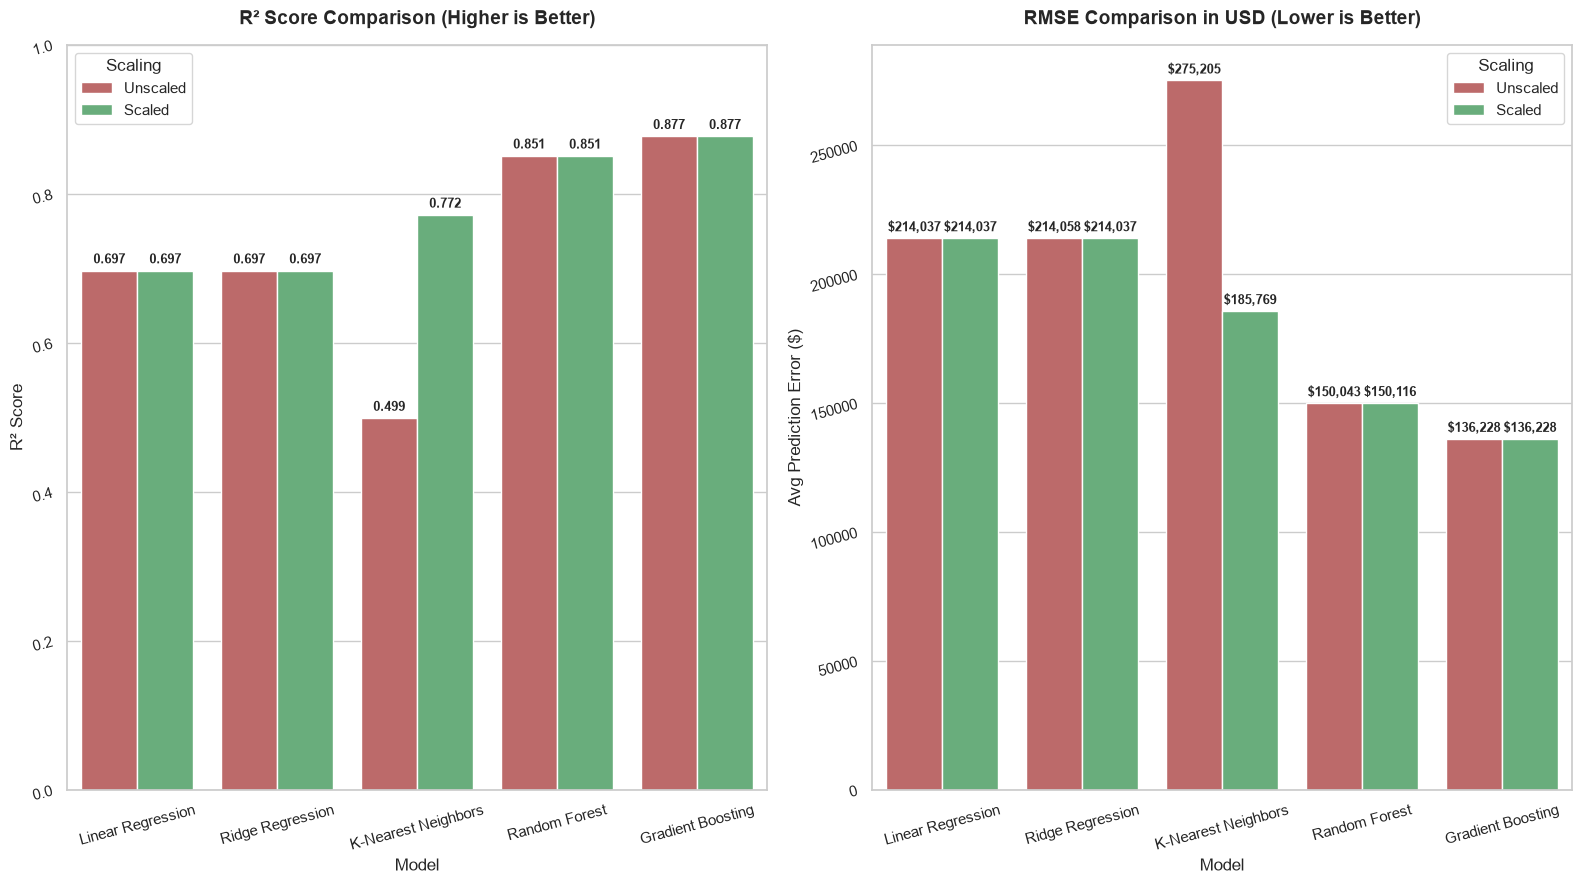

In [33]:
comparison_chart_data = {
    'Model': [
        'Linear Regression', 'Linear Regression',
        'Ridge Regression', 'Ridge Regression',
        'K-Nearest Neighbors', 'K-Nearest Neighbors',
        'Random Forest', 'Random Forest',
        'Gradient Boosting', 'Gradient Boosting'
    ],
    'Scaling': [
        'Unscaled', 'Scaled',
        'Unscaled', 'Scaled',
        'Unscaled', 'Scaled',
        'Unscaled', 'Scaled',
        'Unscaled', 'Scaled'
    ],
    'R2': [
        r2_lr_unscaled, r2_lr_scaled,
        r2_ridge_unscaled, r2_ridge_scaled,
        r2_knn_unscaled, r2_knn_scaled,
        r2_rf_unscaled, r2_rf_scaled,
        r2_hgb_unscaled, r2_hgb_scaled
    ],
    'RMSE': [
        rmse_lr_unscaled, rmse_lr_scaled,
        rmse_ridge_unscaled, rmse_ridge_scaled,
        rmse_knn_unscaled, rmse_knn_scaled,
        rmse_rf_unscaled, rmse_rf_scaled,
        rmse_hgb_unscaled, rmse_hgb_scaled
    ]
}

df = pd.DataFrame(comparison_chart_data)

# 2. Setup the plotting canvas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Left Plot: R2 (Higher is better)
sns.barplot(x='Model', y='R2', hue='Scaling', data=df, ax=axes[0], palette=['#C95D5D', "#5DB977"])
axes[0].set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.0)
axes[0].tick_params(rotation = 15)

# Annotate values on the R2 bars
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, fontweight='bold')

# Right Plot: RMSE (Lower is better)
sns.barplot(x='Model', y='RMSE', hue='Scaling', data=df, ax=axes[1], palette=["#C95D5D", "#5DB977"])
axes[1].set_title('RMSE Comparison in USD (Lower is Better)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Avg Prediction Error ($)')
axes[1].tick_params(rotation = 15)

# Annotate values on the RMSE bars
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 11. Identify which features most strongly influence house prices based on your best model.

In [32]:
# Initialize the regressor for predicting house prices
model = xgb.XGBRegressor(
    n_estimators=100,      # Number of gradient boosted trees
    learning_rate=0.1,     # Step size shrinkage to prevent overfitting
    max_depth=6,           # Maximum depth of a tree
    random_state=42
)

# Fit to your training data (where y_train is the 'price' column)
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None
